<a href="https://colab.research.google.com/github/Whizz-tamie/gnn-indaba-2026/blob/main/notebooks/GNN_Tutorial_TakeHome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Networks: Foundations and Applications for Real-World Networks
### Deep Learning Indaba 2026 — Take-Home Notebook

*Prepared by Godbless James*

This notebook is the **full companion** to the shorter [Live notebook](https://colab.research.google.com/drive/1SslIurE2t49hWKaH7fCNbIumOWG1zFvp#scrollTo=sn4-XFN6X9Gn).
Where the live notebook focuses on a small number of ideas — a baseline, a GCN, and an
ablation showing what graph structure contributes on its own — this notebook covers
everything else: the dataset in depth, the subsampling rationale, a Graph Attention
Network extension, a small graph visualisation, exercises, and further reading.

**Dataset**: [Synthetic Mobile Money Transaction Dataset (1.72M transactions)](https://data.mendeley.com/datasets/zhj366m53p/2),
developed by Denish Azamuke, Marriette Katarahweire, and Engineer Bainomugisha at
Makerere University, Kampala. Calibrated against real Sub-Saharan mobile money
transaction data and licensed under CC BY 4.0.

## Learning objectives

By the end of this notebook, you will be able to:
- Recognise when a problem is naturally framed as a graph and articulate why standard
  machine learning methods underuse the relational signal
- Construct a graph object from raw tabular records, including nodes, edges, a feature
  matrix, and labels
- Explain message passing as the unifying mechanism behind Graph Neural Networks
- Implement and train a Graph Convolutional Network using PyTorch Geometric
- Evaluate node classification models on imbalanced data using appropriate metrics,
  against a non-graph baseline
- Understand conceptually how a Graph Attention Network extends the GCN with learned
  attention weights, as a foundation for building and evaluating one yourself

## Prerequisites

Basic Python; linear algebra at a conceptual level (vectors, matrix multiplication);
supervised learning fundamentals (loss functions, gradient-based optimisation). No prior
graph theory or GNN knowledge is required — all necessary background is covered here.

## About the Dataset

The Synthetic Mobile Money Transaction Dataset was developed at the Department of Computer Science, Makerere University, Kampala. The simulation methodology is described in Azamuke, Katarahweire, and Bainomugisha (*IEEE Access*, 2024), and the dataset itself is documented in the companion data article (*Data in Brief*, 2025). The platform was built using the MASON multi-agent simulation toolkit and calibrated against real mobile money transaction data from Sub-Saharan Africa, with fidelity verified through Kolmogorov-Smirnov tests, Bland-Altman plots, and the sum-of-squared-errors method.

### Agents

The simulation models four agent types in the following populations:

- **Clients**: 3,000 individual mobile money users who initiate all transactions
- **Mobile money merchants**: 1,500 entities that facilitate cash-to-electronic conversion and serve as transaction endpoints
- **Banks**: 10 institutions that receive debits from clients moving money to traditional bank accounts
- **Fraudsters**: 1,000 actors playing a behavioural role overlaid on clients or merchants, not a separate entity class

Note that the dataset distinguishes banks from non-banks through the recipient ID prefix, but does not distinguish clients from merchants by ID alone. The agent type of a non-bank recipient can be inferred from the transaction type (PAYMENT, DEPOSIT, and WITHDRAWAL go to merchants; TRANSFER goes to other clients).

### Transaction types

Every transaction originates from a client. The recipient varies by type:

- **Deposit**: cash placed into an account via a merchant
- **Withdrawal**: cash removed from an account via a merchant
- **Transfer**: money sent from one client to another
- **Payment**: money sent from a client to a merchant for goods or services
- **Debit**: money moved from a client's account to a bank account

### Fraud typologies

MoMTSim simulates three named fraud scenarios, each with distinct behavioural signatures:

- **Account takeover** (via SIM swaps or lost credentials): a fraudster gains control of a victim's account and uses it to drain funds, typically through transfers or withdrawals via merchants.
- **Refund fraud**: a fraudster makes payments to retailers and repeatedly requests refunds, sometimes involving new victims. The fraudster eventually withdraws the proceeds.
- **Fake credentials**: a fraudster creates new mobile money accounts using stolen identifiers (phone number, email, or national identification number) and conducts fraudulent transactions under those false identities.

These typologies share a common structural feature: fraud appears as patterns of *connections* between accounts (repeated payments to the same merchant, transfers to new victims, multiple accounts behaving similarly because they share an external controller). This is precisely the signal a Graph Neural Network is designed to capture.

### Simulation parameters

One simulation step represents one hour, and the full simulation runs for 720 steps, approximating one month of activity. This notebook works with a six-day slice of that output (steps 0 to 143). Fraud is parameterised through explicitly relational probabilities: the likelihood that a fraudulent client reuses a previous merchant (the favourite-merchant pattern) and the likelihood of targeting new victims.

### Schema

Each row in the dataset describes one transaction:

- `step`: timestamp (1 step = 1 hour)
- `transactionType`: one of DEPOSIT, WITHDRAWAL, TRANSFER, PAYMENT, DEBIT
- `amount`: transaction amount
- `initiator`: client identifier
- `oldBalInitiator`, `newBalInitiator`: client balance before and after the transaction
- `recipient`: receiving party identifier (a leading "B" indicates a bank account; other recipients are clients or merchants and are not distinguished by the identifier alone)
- `oldBalRecipient`, `newBalRecipient`: recipient balance before and after the transaction
- `isFraud`: binary label (1 = fraudulent, 0 = legitimate)

### Validation

The authors validated the synthetic data against real Sub-Saharan transactions. Kolmogorov-Smirnov tests returned high p-values (0.838 for transaction count and average value, 0.996 for total value) with very low KS statistics, indicating the synthetic and real distributions closely match. This validation underwrites the dataset's use for machine learning research in settings where access to real mobile money data is restricted.

## 1. Setup

In [1]:
!pip install -q torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.utils import to_undirected
from sklearn.metrics import precision_score, recall_score, roc_auc_score, average_precision_score

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cpu
CUDA available: False


## 2. Load the data

This notebook works with the same prepared sample used in the live session — a subsampled,
graph-dense slice of the full MoMTSim dataset (see Section 4 for how and why it was built
this way). It downloads automatically below, so no manual upload is needed.

In [3]:
!wget -q "https://raw.githubusercontent.com/Whizz-tamie/gnn-indaba-2026/refs/heads/main/data/momtsim_sample.csv" -O momtsim_sample.csv
df_full = pd.read_csv('momtsim_sample.csv')
df_full['initiator'] = df_full['initiator'].astype(str)
df_full['recipient'] = df_full['recipient'].astype(str)
print(f"Shape: {df_full.shape}")
df_full.head()

Shape: (50000, 10)


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,65,TRANSFER,18121.98,4251822106706232,4859621.86,4841499.88,4037533641984801,23795.04,41917.02,0
1,41,DEPOSIT,105462.76,4409271508181738,4505505.11,4610967.87,61-0007655,97397.35,97397.35,0
2,127,TRANSFER,39246.31,4360579409293775,1418990.65,1379744.34,4904942044067710,134020.81,173267.12,1
3,29,TRANSFER,42289.90,4210469501637180,2671271.06,2628981.16,4167790825993378,42359.92,84649.82,0
4,124,TRANSFER,17259.03,4197201698266276,3586965.40,3569706.37,4275853117454845,98396.93,115655.95,0


**Want the full 1.72M-row dataset** — to inspect it yourself, or to rerun `prepare_data.py`
with different subsampling choices? Get it directly from [Mendeley Data](https://data.mendeley.com/datasets/zhj366m53p/2).
That's what produced the sample loaded above; Section 4 explains the subsampling logic.

## 3. Exploratory data analysis

Let's take some time to understand the data before building anything from it. The five views below characterise the dataset along the dimensions most relevant to graph-based learning: schema and types, transaction-type composition, where fraud lives, the amount distribution, and the activity distribution per initiator.

### 3.1 Schema and types

Confirm the columns match the schema described above and inspect dtypes. Notice that `initiator` and `recipient` have different dtypes (`int64` and `object` respectively). This is a deliberate design choice: initiators are always clients and therefore share a single identifier scheme, while recipients span clients, merchants, and banks and carry string prefixes that encode the agent type.

In [4]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   step             50000 non-null  int64  
 1   transactionType  50000 non-null  object 
 2   amount           50000 non-null  float64
 3   initiator        50000 non-null  object 
 4   oldBalInitiator  50000 non-null  float64
 5   newBalInitiator  50000 non-null  float64
 6   recipient        50000 non-null  object 
 7   oldBalRecipient  50000 non-null  float64
 8   newBalRecipient  50000 non-null  float64
 9   isFraud          50000 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 3.8+ MB


In [5]:
print("Missing values per column:")
print(df_full.isna().sum())
print(f"\nFraud rate: {df_full['isFraud'].mean() * 100:.2f}%")
print(f"Time span: step {df_full['step'].min()} to {df_full['step'].max()} "
      f"({df_full['step'].max() / 24:.1f} days)")

Missing values per column:
step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64

Fraud rate: 10.14%
Time span: step 0 to 143 (6.0 days)


### 3.2 Transaction-type composition

Different transaction types correspond to different agent pairings: client-to-merchant for deposits, withdrawals, and payments; client-to-client for transfers; client-to-bank for debits. The transaction-type mix therefore determines what kinds of edges the graph will contain and in what proportion.

transactionType
PAYMENT       19568
TRANSFER      17328
DEPOSIT        9994
WITHDRAWAL     3005
DEBIT           105
Name: count, dtype: int64


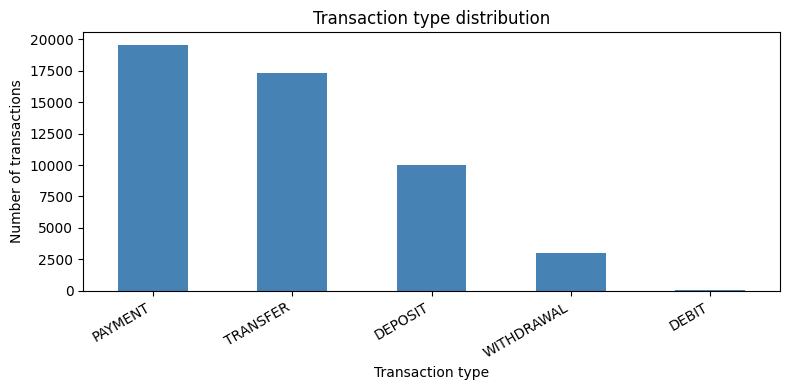

In [6]:
type_counts = df_full['transactionType'].value_counts()
print(type_counts)

fig, ax = plt.subplots(figsize=(8, 4))
type_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Number of transactions')
ax.set_xlabel('Transaction type')
ax.set_title('Transaction type distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**What the chart shows.** PAYMENT dominates at roughly 19,600 transactions, with TRANSFER close behind at around 17,300. Together these two types account for over 70% of all transactions. DEPOSIT sits at around 10,000, WITHDRAWAL at around 3,000, and DEBIT is barely visible on the linear scale (about 100 transactions).

**What this means for the graph.** Translating back to agent pairings, the edge composition will be:
- Roughly two-thirds of edges are client-to-merchant (PAYMENT, DEPOSIT, and WITHDRAWAL combined)
- Roughly one-third are client-to-client (TRANSFER)
- Client-to-bank edges (DEBIT) are present but extremely sparse

Three structural consequences are worth holding onto as we build the graph:

1. **The graph will be hub-and-spoke.** Many client nodes connect to relatively few merchant nodes, giving merchants very high in-degree. Message passing will propagate information from popular merchants widely.
2. **The bank node type is present but barely.** The four-agent design is in the data, just unevenly represented.
3. **Client-to-client TRANSFER edges are where relational fraud patterns most naturally live.** The paper's "reusing favourite merchants" and "targeting new victims" signatures both involve repeated or novel connections between accounts, and TRANSFER is the transaction type where those signatures will be most visible.

### 3.3 Where does fraud live?

The MoMTSim paper notes that fraud concentrates in particular transaction types rather than spreading uniformly. Computing the fraud rate per type identifies which edges in the graph are riskiest, and points to where a GNN's neighbourhood-aware reasoning is most likely to add value.

                 fraud_rate  fraud_count  total_count
transactionType                                      
TRANSFER           0.292475         5068        17328
DEBIT              0.000000            0          105
DEPOSIT            0.000000            0         9994
PAYMENT            0.000000            0        19568
WITHDRAWAL         0.000000            0         3005


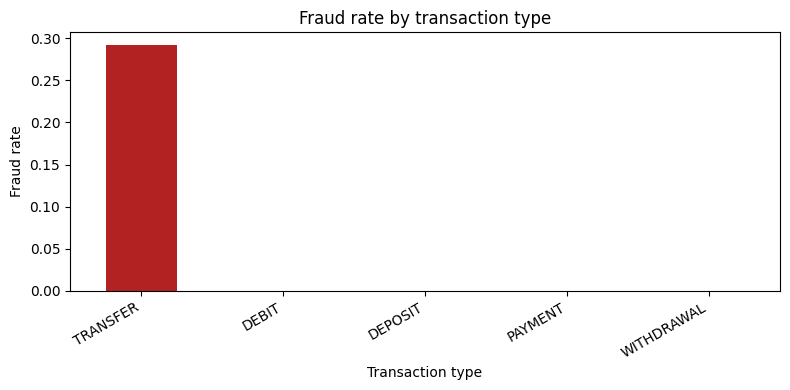

In [7]:
fraud_by_type = df_full.groupby('transactionType')['isFraud'].agg(['mean', 'sum', 'count'])
fraud_by_type.columns = ['fraud_rate', 'fraud_count', 'total_count']
fraud_by_type = fraud_by_type.sort_values('fraud_rate', ascending=False)
print(fraud_by_type)

fig, ax = plt.subplots(figsize=(8, 4))
fraud_by_type['fraud_rate'].plot(kind='bar', ax=ax, color='firebrick')
ax.set_ylabel('Fraud rate')
ax.set_xlabel('Transaction type')
ax.set_title('Fraud rate by transaction type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**The result is unusually clean.** Every single fraudulent transaction in the dataset is a TRANSFER. The other four transaction types — PAYMENT, DEPOSIT, WITHDRAWAL, and DEBIT — contain no fraud at all. Within TRANSFER itself, the fraud rate is 29.2%: roughly one in three client-to-client transfers is fraudulent.

**This is a strong design choice by the dataset authors, and it reshapes how we think about the problem.** Fraud in this simulation is entirely a client-to-client phenomenon. It lives in the part of the transaction graph where one client sends money to another, which matches the paper's description of relational fraud patterns: a fraudulent client targeting new victims, or reusing a favourite contact, both manifest through TRANSFER edges. Client-to-merchant activity (PAYMENT, DEPOSIT, WITHDRAWAL) and client-to-bank activity (DEBIT) are entirely legitimate by construction.

**Practical implications for the rest of this notebook.** A GNN trained on the full graph still benefits from the merchant and bank edges as context — a fraudulent account's broader behavioural signature includes how it pays, deposits, and withdraws — but the fraud signal itself lives in the client-to-client subgraph. When you reach the model training section and the GAT starts learning attention weights, expect those weights to concentrate on TRANSFER edges. A model that ignored the other edge types entirely would still catch most fraud here, which is something to keep in mind when reading the final metrics.

### 3.4 Amount distribution

Transaction amounts in financial data are heavy-tailed, with a long right tail of large transactions sitting alongside many small ones. Comparing the fraud and legitimate distributions on a log scale reveals whether amount alone separates the two classes — a question that bears directly on how much of the fraud problem is captured by per-transaction features and how much remains for the graph structure to explain.

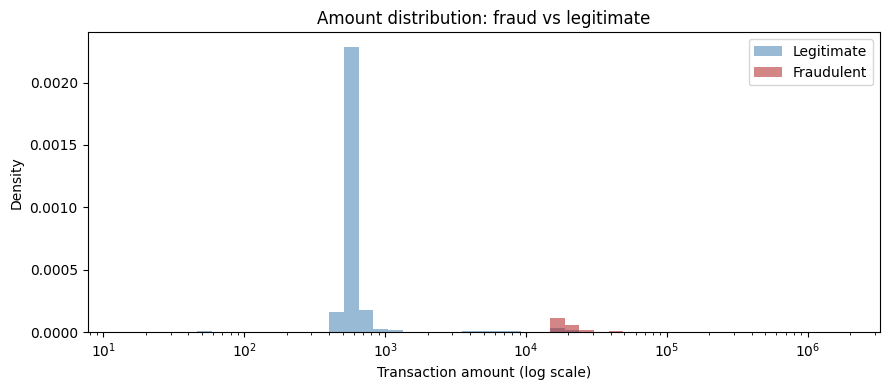

Legitimate: median 17,024, mean 54,157
Fraudulent: median 19,653, mean 25,797


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
legit_amt = df_full.loc[df_full['isFraud'] == 0, 'amount']
fraud_amt = df_full.loc[df_full['isFraud'] == 1, 'amount']

bins = np.logspace(np.log10(max(legit_amt.min(), 0.01)),
                    np.log10(legit_amt.max()), 50)
ax.hist(legit_amt, bins=bins, alpha=0.55, label='Legitimate', color='steelblue', density=True)
ax.hist(fraud_amt, bins=bins, alpha=0.55, label='Fraudulent', color='firebrick', density=True)
ax.set_xscale('log')
ax.set_xlabel('Transaction amount (log scale)')
ax.set_ylabel('Density')
ax.set_title('Amount distribution: fraud vs legitimate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Legitimate: median {legit_amt.median():,.0f}, mean {legit_amt.mean():,.0f}")
print(f"Fraudulent: median {fraud_amt.median():,.0f}, mean {fraud_amt.mean():,.0f}")

**The two distributions barely overlap.** Legitimate transactions cluster tightly around 500-1000 monetary units (the tall blue peak), while fraudulent transactions sit in a different band entirely, concentrated around 10,000-30,000 units (the red peak well to the right). On a log scale these clusters are visibly separated by more than an order of magnitude.

**The headline summary statistics are misleading on their own.** The medians (17,024 legitimate vs 19,653 fraudulent) suggest the two classes are similar. The means tell a different story (54,157 legitimate vs 25,797 fraudulent), and the visualisation tells yet another (the *modes* are very far apart, even if the tails interleave). The lesson: for heavy-tailed financial data, summary statistics can obscure separability that the distributions themselves reveal.

**What this means for the rest of the notebook.** Transaction amount is a strong individual signal here. A model that uses amount even crudely will already do well. This sets the bar high for what the graph structure needs to add: the GNN cannot win by rediscovering the amount signal, it has to find structural patterns that an aggregate-feature model would miss. Keep this in mind when reading the final metrics in Section 9.

### 3.5 Activity distribution per initiator

How many transactions does each client initiate? Mobile money activity is typically heavy-tailed: a small number of accounts are very active, and most accounts transact sporadically. The two plots below check whether that pattern holds in this dataset and quantify how concentrated the activity is.

Number of unique initiators: 3,000
Total transactions:          50,000
Mean transactions/initiator: 16.7
Median:                      14
Top 1% threshold:            47
Maximum:                     83


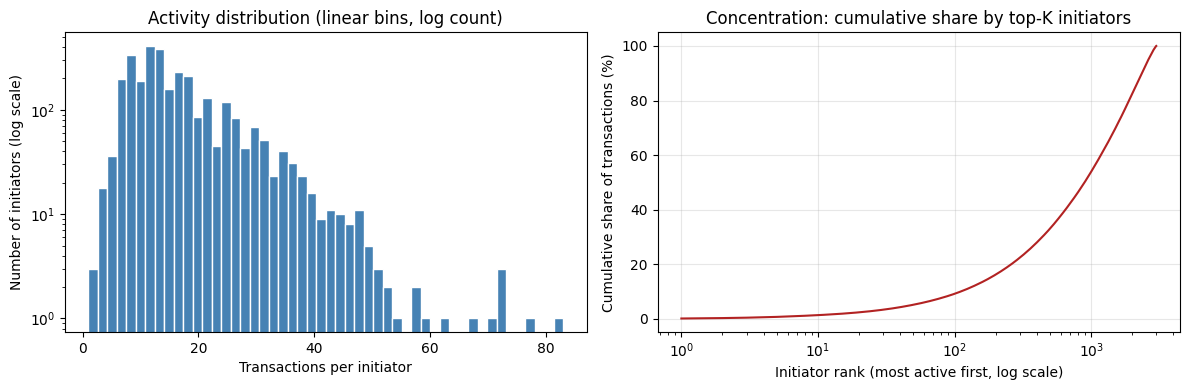

In [9]:
tx_per_initiator = df_full['initiator'].value_counts()
print(f"Number of unique initiators: {len(tx_per_initiator):,}")
print(f"Total transactions:          {len(df_full):,}")
print(f"Mean transactions/initiator: {tx_per_initiator.mean():.1f}")
print(f"Median:                      {tx_per_initiator.median():.0f}")
print(f"Top 1% threshold:            {tx_per_initiator.quantile(0.99):.0f}")
print(f"Maximum:                     {tx_per_initiator.max()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(tx_per_initiator.values, bins=50, color='steelblue', edgecolor='white')
ax1.set_yscale('log')
ax1.set_xlabel('Transactions per initiator')
ax1.set_ylabel('Number of initiators (log scale)')
ax1.set_title('Activity distribution (linear bins, log count)')

sorted_counts = np.sort(tx_per_initiator.values)[::-1]
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
ax2.plot(np.arange(1, len(cumulative) + 1), cumulative, color='firebrick')
ax2.set_xscale('log')
ax2.set_xlabel('Initiator rank (most active first, log scale)')
ax2.set_ylabel('Cumulative share of transactions (%)')
ax2.set_title('Concentration: cumulative share by top-K initiators')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The hypothesis holds, even within an already-filtered sample.** This sample was built by keeping only the 3,000 most active initiators from the full dataset (Section 4 explains why), so it's already denser than a random slice would be — and the activity distribution is still visibly right-skewed. The histogram on the left shows most initiators clustered at lower transaction counts, with a tail stretching out toward the maximum of 83 transactions for the most active account in the sample.

**The concentration is real but modest, which is expected.** Within this pre-filtered sample: the top 100 most active initiators account for about 9% of all transactions, and the top 1,000 for about 54%. (The "top 3,000" figure isn't meaningful here — the sample only contains 3,000 initiators in total, so that's trivially 100%.) This is a gentler skew than you'd see in the full 1.72M-row dataset, precisely because the subsampling already selected for activity.

**The headline numbers reinforce the picture.** The mean (16.7 transactions per initiator) is noticeably higher than the median (14), the standard fingerprint of a right-skewed distribution, even though the effect is much less extreme than in the full dataset. The top 1% of accounts each initiate at least 47 transactions over six days.

**Two structural observations to carry forward.** First, the full 1.72M-row dataset spans over 13,000 initiators — far too many, and far too sparse per account, for a useful message-passing graph if sampled randomly. Second, the fact that a relatively small set of accounts already handles a disproportionate share of transactions is exactly what active-account subsampling exploits: keeping the busiest accounts concentrates the edges this sample does have, rather than spreading them thin. Section 4 examines this rationale directly.

## 4. Why this sample: the active-account subsampling rationale

*(This section explains reasoning only — the sample was already built by `prepare_data.py`
and loaded in Section 2, so there's no subsampling code to run here. This mirrors exactly
what that script does.)*

The full dataset has 1.72 million transactions across more than 13,000 initiators — too
large and too sparse for a live-session graph (most accounts would end up with very few
transactions, giving message passing little to work with). `prepare_data.py` keeps
transactions from the **3,000 most active initiators**, then caps the result at 200,000
transactions (stratified by fraud label, so the fraud rate is preserved) for tractable
training. That combination trades breadth for density: fewer accounts, but each with
enough transaction history for the GNN to learn from.

### A quick look at who the recipients are

The first character of each recipient ID encodes one piece of information about the agent type. A single `value_counts` on the prefix reveals it.

In [10]:
print("Recipient prefix distribution:")
print(df_full['recipient'].str[0].value_counts())

Recipient prefix distribution:
recipient
4    20160
5     3975
3     3928
8     3796
6     3777
9     3231
7     3012
2     2770
0     2676
1     2570
B      105
Name: count, dtype: int64


**The prefix distinguishes bank recipients from everything else.** Recipients starting with "B" are bank accounts; there are 105 of them in the subsample, matching the small DEBIT share (~0.2%) we saw in the transaction-type composition. The remaining recipients have purely numeric IDs (first character 0-9), which means client and merchant recipients are not distinguished by their identifier alone in this dataset.

**This limits how heterogeneous our analysis can be without extra work.** From the recipient ID alone we can tell banks apart from non-banks, but to distinguish merchants (PAYMENT, DEPOSIT, WITHDRAWAL recipients) from clients (TRANSFER recipients) we would need to cross-reference the `transactionType` of each transaction. We won't do that in this tutorial — we treat the graph as homogeneous for clarity — but it's worth knowing the information is recoverable for anyone building a heterogeneous GNN later.

In [11]:
# Quick check: do "B"-prefixed recipients only appear in DEBIT?
b_check = df_full[df_full['recipient'].str.startswith('B')]['transactionType'].value_counts()
print(b_check)

transactionType
DEBIT    105
Name: count, dtype: int64


## 5. From CSV to graph

The CSV is a list of transactions. The graph is a network of accounts. The data is the same; only the representation changes. This section makes that change concrete.

**The mapping**:
- Each unique account in `initiator` or `recipient` becomes a **node**
- Each transaction becomes a **directed edge** from sender to recipient
- Per-account aggregated statistics (transaction counts, amounts, net flow) become the **node feature matrix** $X$
- An account is labelled **fraudulent** if it ever initiated a fraudulent transaction

### A brief word on PyTorch Geometric

This notebook uses **PyTorch Geometric** (often shortened to **PyG**), a most widely adopted library for building GNNs in PyTorch. PyG handles three things for us:

- **A graph data structure.** The `Data` object holds nodes, edges, node features, edge features, and labels in one tensor-based container that lives happily on a GPU.
- **Pre-built GNN layers.** `GCNConv`, `GATConv`, and most other published architectures are available as drop-in modules, so building a GNN feels much like building a standard PyTorch model.
- **Efficient message passing.** PyG implements the gather-scatter operations behind message passing in a way that scales to large graphs.

You can think of PyG as doing for graphs what `torch.nn` does for tensors: providing the primitives so you can focus on the model design rather than the plumbing. The remainder of this notebook will progressively introduce its key conventions (the `edge_index` tensor, the `Data` object, the `GCNConv` and `GATConv` layers) at the moment each one is needed.

In [12]:
# Step 1 — Collect unique accounts and assign each an integer index.
# PyTorch Geometric refers to nodes by 0..N-1 integer IDs, so we build a
# lookup from account string to index that we'll reuse for edges and features.
all_accounts = pd.Index(pd.concat([df_full['initiator'], df_full['recipient']]).unique())
account_to_idx = {acc: i for i, acc in enumerate(all_accounts)}
n_nodes = len(all_accounts)
print(f"Number of unique accounts (nodes): {n_nodes:,}")

Number of unique accounts (nodes): 13,237


**What this number tells us.** 13,237 unique accounts from 50,000 transactions gives an average directed degree of about 3.8 — meaning each account, on average, is directly connected to about 4 others through transactions in this six-day window, counting direction. That's noticeably denser than a random slice of the full 1.72M-row dataset would produce (where the same 50,000 transactions would scatter across far more distinct accounts), though as we'll see once we account for direction, the effective density the model trains on is higher still.

Note also that this number is below the upper bound of 13,380 we'd get from `3,000 + 10,380` (initiators plus recipients), which means some accounts appear on both sides of transactions — clients who both send and receive money, as you would expect in any real mobile money system.

**A note on direction.** These edges are directed (initiator → recipient), matching how
the transaction actually happened. When we assemble the graph object below, we convert
to undirected — see the note in that step for why.

In [13]:
src_ = df_full['initiator'].map(account_to_idx).to_numpy()
dst_ = df_full['recipient'].map(account_to_idx).to_numpy()
edge_index_directed = torch.tensor(np.stack([src_, dst_]), dtype=torch.long)
print(f"edge_index shape: {tuple(edge_index_directed.shape)}  (2 x num_edges, directed)")
print(f"Average degree (edges per node): {edge_index_directed.shape[1] / n_nodes:.2f}")
print(f"First three edges (source -> destination):")
for i in range(3):
    s_idx, d_idx = edge_index_directed[0, i].item(), edge_index_directed[1, i].item()
    print(f"  {all_accounts[s_idx]} -> {all_accounts[d_idx]}")

edge_index shape: (2, 50000)  (2 x num_edges, directed)
Average degree (edges per node): 3.78
First three edges (source -> destination):
  4251822106706232 -> 4037533641984801
  4409271508181738 -> 61-0007655
  4360579409293775 -> 4904942044067710


**Density confirmed, and a decision to make.** The graph above is directed. PyTorch
Geometric aggregates information *into* a node from its incoming edges — but our fraud
labels sit on **initiators**, most of whom mostly *send* rather than receive. Left
directed, a labelled fraud account would only aggregate neighbourhood information on the
occasions it happens to also be someone's recipient, discarding most of the relational
signal (who it paid, how often, to whom) that message passing is supposed to exploit.

For this tutorial we resolve this by converting to an **undirected** graph with
`torch_geometric.utils.to_undirected` — every account then aggregates over everyone it
transacted with, sender or receiver. This is the simplest fix for an introductory example.
Two alternatives worth knowing about: adding explicit reverse edges (keeps directionality
recoverable, useful if you later want direction-aware or heterogeneous models — see
Exercise 3), or leaving it directed and explaining the asymmetry to participants directly.
We chose undirected because it keeps the graph-construction story simple while participants
are still learning the vocabulary; direction-aware modelling is a natural next step once
message passing itself is understood.

In [14]:
from torch_geometric.utils import to_undirected
edge_index = to_undirected(edge_index_directed)
print(f"edge_index shape after to_undirected: {tuple(edge_index.shape)}")
print(f"Average degree: {edge_index.shape[1] / n_nodes:.2f}")

edge_index shape after to_undirected: (2, 92048)
Average degree: 6.95


### Step 3 — Build the node feature matrix X

Each node in the graph needs a feature vector. The graph topology alone tells the GNN who is connected to whom, but message passing also needs *content* to pass between nodes. Feature vectors give the model something to start from.

For a transaction graph, the natural source of node features is the **aggregated activity** of each account. Below we compute, for every account:

- **Outgoing statistics**: how many transactions the account initiated, the total and average amount sent, and the largest single outgoing amount
- **Incoming statistics**: the same four quantities for transactions where the account was the recipient
- **Two derived features**: total transaction count (in + out) and net flow (in − out)

This gives ten numerical features per account. Two design choices are worth flagging:

- **Log-scale standardisation.** Monetary features are heavy-tailed (we saw this in EDA Section 3.4), so raw amounts would let large transactions dominate the loss surface. Applying `log(1 + |x|)` compresses the tail before standardising to zero mean and unit variance.
- **Accounts with no outgoing or no incoming activity.** A merchant that only receives payments has no outgoing transactions, and its outgoing feature columns are filled with zeros. This is the right behaviour — a zero in the standardised space represents "average activity", and zero outgoing transactions is below average, which is what these accounts deserve.

In [15]:
# Step 3 — Build the node feature matrix X.

# Aggregate outgoing activity per initiator and incoming activity per recipient.
sent = df_full.groupby('initiator').agg(
    out_count=('amount','size'), out_sum=('amount','sum'),
    out_mean=('amount','mean'), out_max=('amount','max'))
recv = df_full.groupby('recipient').agg(
    in_count=('amount','size'), in_sum=('amount','sum'),
    in_mean=('amount','mean'), in_max=('amount','max'))

# Join the two views by account ID; accounts missing from one side get zero features there.
features = pd.DataFrame(index=all_accounts).join(sent).join(recv).fillna(0.0)
features['tx_total'] = features['out_count'] + features['in_count']
features['net_flow'] = features['in_sum'] - features['out_sum']

# Log-compress the heavy tails, then standardise to zero mean and unit variance.
X_raw = features.to_numpy(dtype=np.float32)
X_log = np.sign(X_raw) * np.log1p(np.abs(X_raw))
X_std = (X_log - X_log.mean(axis=0)) / (X_log.std(axis=0) + 1e-9)

x = torch.tensor(X_std, dtype=torch.float32)
print(f"Node feature matrix X: {tuple(x.shape)}  (num_nodes x num_features)")
print(f"Feature columns: {list(features.columns)}")

Node feature matrix X: (13237, 10)  (num_nodes x num_features)
Feature columns: ['out_count', 'out_sum', 'out_mean', 'out_max', 'in_count', 'in_sum', 'in_mean', 'in_max', 'tx_total', 'net_flow']


**What we have.** Every account in the graph now carries a ten-dimensional feature vector summarising its transaction behaviour. The model will combine these per-node features with the message-passing structure from `edge_index` to learn account-level representations.

Note that these features describe each account *in isolation* — they encode what each account does, not who it transacts with. The graph structure carries the relational information. This separation is deliberate: it lets us see, later in the notebook, whether the GNN can extract value from the relational signal beyond what the per-account features already provide.

### Step 4 — Build node-level labels

The original `isFraud` column lives on *transactions* — each row is either fraudulent or legitimate. But our task is to flag *accounts*, not individual transactions, so the labels need to move from edges to nodes.

The rule used here is straightforward: **an account is labelled fraudulent if it ever initiated at least one fraudulent transaction.** Everyone else is labelled legitimate.

Two things worth noting about this choice:

- **Why initiator-only?** Fraud in this dataset always originates from the sender side — a victim of fraud, when their account is taken over, becomes effectively a fraudster's tool. Marking recipients as fraudulent would mean labelling victims, which is not what we want to detect.
- **The threshold is lenient.** A single fraudulent transaction marks the whole account. We could require a higher count, or a higher fraction of the account's activity, but for a tutorial the simple rule is the right one — it gives the model the cleanest possible target.

In [16]:
# Step 4 — Build node-level labels.
# An account is labelled fraudulent if it ever appeared as the initiator
# of a fraudulent transaction in the working set.
fraud_accounts = set(df_full.loc[df_full['isFraud'] == 1, 'initiator'].unique())
y = torch.tensor([1 if acc in fraud_accounts else 0 for acc in all_accounts], dtype=torch.long)
print(f"Fraudulent accounts: {int(y.sum())} of {n_nodes} ({y.float().mean()*100:.2f}%)")

Fraudulent accounts: 2317 of 13237 (17.50%)


**The account-level fraud rate is roughly double the transaction-level rate** (17.50% versus 10.14% per transaction). This is the expected consequence of the labelling rule: a single fraudulent transaction marks an entire account, so accounts that initiate many transactions — some fraudulent, most not — still count as one fraudulent node. With most fraudsters concentrated in the active-account pool we filtered to in Section 4, the per-node rate inflates accordingly.

**What this means for training.** The class imbalance is now roughly 1-in-6 rather than 1-in-10. Still imbalanced enough that accuracy is a misleading metric (a model predicting "legitimate" for every account would score 82.50%), but mild enough that class-weighted loss should handle it without aggressive intervention. We'll see this play out in the training section.

### Step 5 — Train/val/test masks

In conventional supervised learning, the train/val/test split is a physical partition: three separate datasets, each with its own examples. For node classification on a graph this doesn't work, because the graph is one connected object. Removing test nodes during training would also remove the edges connecting them to training nodes, changing the very structure the model is meant to learn from.

The solution is **masking**. The model sees the full graph and computes representations for every node, but:

- During training, the loss is computed only on the training nodes
- During validation, metrics are evaluated only on the validation nodes
- During testing, metrics are evaluated only on the test nodes

Each mask is a boolean tensor the length of the node count: `True` for nodes belonging to that split, `False` otherwise. We use a 60/20/20 split here, which is conventional for node classification benchmarks.

In [17]:
# Step 5 — Train/val/test masks.
# In node classification we don't physically separate the graph; instead, three
# boolean masks select which nodes contribute to training, validation, and testing.
torch.manual_seed(42)
perm = torch.randperm(n_nodes)
n_train, n_val = int(0.6 * n_nodes), int(0.2 * n_nodes)
train_mask = torch.zeros(n_nodes, dtype=torch.bool); train_mask[perm[:n_train]] = True
val_mask = torch.zeros(n_nodes, dtype=torch.bool); val_mask[perm[n_train:n_train+n_val]] = True
test_mask = torch.zeros(n_nodes, dtype=torch.bool); test_mask[perm[n_train+n_val:]] = True

print(f"Train: {train_mask.sum().item():,} nodes  |  Val: {val_mask.sum().item():,}  |  Test: {test_mask.sum().item():,}")

Train: 7,942 nodes  |  Val: 2,647  |  Test: 2,648


In [ ]:
print(f"Train fraud rate: {y[train_mask].float().mean()*100:.2f}%")
print(f"Val fraud rate:   {y[val_mask].float().mean()*100:.2f}%")
print(f"Test fraud rate:  {y[test_mask].float().mean()*100:.2f}%")

**The split is well-balanced.** All three subsets sit within a fraction of a percentage point of the global fraud rate (Train 17.62%, Val 17.34%, Test 17.33%). A random shuffle on 13,237 nodes was enough to balance the classes without explicit stratification, which means we can trust comparisons across the splits.

**What the masks enable.** The training loop will use `train_mask` to compute the loss, `val_mask` to monitor progress between epochs and choose hyperparameters, and `test_mask` only at the end for the final reported metrics. The model itself never sees a partial graph — every forward pass uses all 13,237 nodes and all 92,048 (undirected) edges. The masks govern which nodes' *labels* the model is allowed to consult.

### Step 6 — Assemble the PyG Data object

All the pieces — node features, edges, labels, and split masks — now live in separate tensors. PyG's `Data` class is a container that binds them into one object the model and training loop can consume.

This is also the point at which the worked construction is complete. From here on, code that touches the graph will refer to `data.x`, `data.edge_index`, `data.y`, and `data.train_mask` rather than to the individual tensors.

In [18]:
# Step 6 — Assemble the PyG Data object.
# Every tensor we built in Steps 1-5 now sits inside one container that the
# model and training loop will consume directly.
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
print(data)

Data(x=[13237, 10], edge_index=[2, 92048], y=[13237], train_mask=[13237], val_mask=[13237], test_mask=[13237])


**Every dimension lines up.** Reading the printout left to right: 13,237 nodes each with a 10-dimensional feature vector, 92,048 undirected edges, one label per node, and three masks of the same length partitioning those nodes into training, validation, and test sets. The CSV-to-graph construction is complete.

**What changed and what didn't.** The underlying data is the same as the working DataFrame we built in Section 3 — same accounts, same transactions, same fraud labels. The representation is what changed. The model that consumes this `Data` object cannot tell whether the underlying source was a CSV, a database, or an API; all it sees is the four tensors. This is the value of the construction: once it's done, the rest of the notebook works the same way it would on any other graph-structured problem.

### A glance at the constructed graph

A 13,237-node graph cannot be visualised in full and remain readable. Instead, the cell below extracts a small neighbourhood around a few fraudulent accounts and draws it with their direct contacts. Red nodes are fraudulent, blue are legitimate, arrows show the direction of transactions. This is for intuition only; the trained model operates on the whole graph.

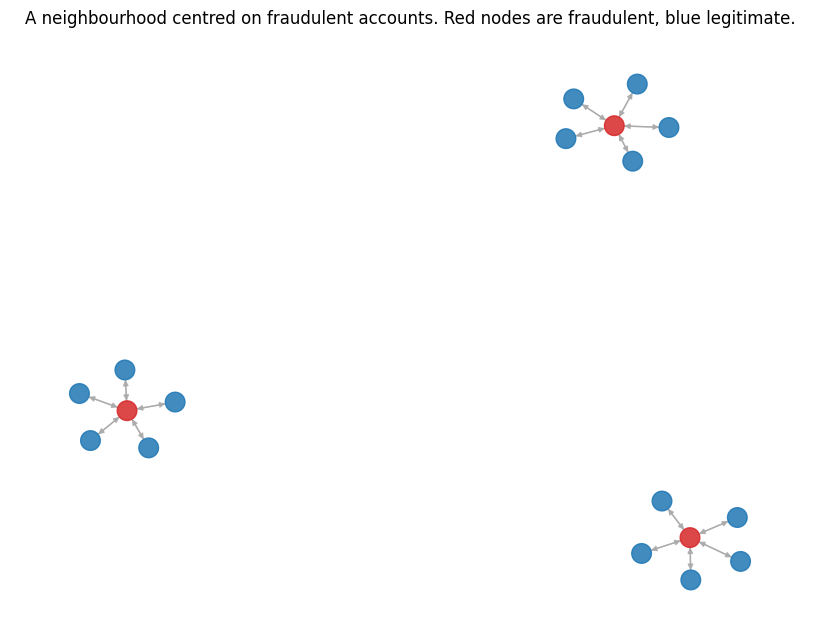

In [19]:
import networkx as nx

fraud_idx = (y == 1).nonzero(as_tuple=True)[0].tolist()
if len(fraud_idx) >= 3:
    # Pick a few fraudulent seed nodes and gather their immediate neighbourhood.
    seeds = fraud_idx[:3]
    nbrs = set(seeds)
    for s in seeds:
        out_neighbours = edge_index[1, edge_index[0] == s].tolist()[:5]
        in_neighbours = edge_index[0, edge_index[1] == s].tolist()[:5]
        nbrs.update(out_neighbours + in_neighbours)
    nbrs = list(nbrs)[:25]
    node_set = set(nbrs)

    # Vectorised edge filtering: keep only edges where both endpoints are in our subset.
    src_in = torch.isin(edge_index[0], torch.tensor(list(node_set)))
    dst_in = torch.isin(edge_index[1], torch.tensor(list(node_set)))
    mask = src_in & dst_in
    sub_edges = edge_index[:, mask].t().tolist()

    G = nx.DiGraph()
    for n in nbrs:
        G.add_node(n, fraud=int(y[n].item()))
    G.add_edges_from(sub_edges)

    colours = ['#d62728' if G.nodes[n]['fraud'] else '#1f77b4' for n in G.nodes]
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=colours, with_labels=False, node_size=200,
            arrows=True, arrowsize=8, edge_color='#aaa', alpha=0.85)
    plt.title('A neighbourhood centred on fraudulent accounts. Red nodes are fraudulent, blue legitimate.')
    plt.show()
else:
    print("Not enough fraud nodes in this subsample to plot a meaningful subgraph.")

**Three structural observations from the layout.**

The fraudulent accounts cluster together rather than scattering across the visualisation. At least four red nodes sit within direct edge-distance of other red nodes, which is exactly the kind of local homophily a Graph Neural Network can exploit. If two accounts are connected and one is fraudulent, the other is more likely to be fraudulent than the global rate would suggest. Message passing turns this into a learnable feature.

The legitimate contacts fan outward from the fraudulent cluster in a hub-and-spoke pattern. This matches what we saw earlier in the transaction-type composition: fraudulent accounts connect to many distinct legitimate accounts (presumably victims), but the legitimate accounts don't necessarily connect to each other. The fraud cluster is the structural centre of this small neighbourhood.

These are the patterns the model will be asked to learn — not from a single visualised neighbourhood but from the statistical signal carried by all 92,048 edges in the full graph.

## 6. Baseline: does the graph structure actually help?

Before reaching for a GNN, it's worth asking a more basic question: how far do the node
features alone get you, with no notion of graph structure at all? We start with a simple
MLP trained on the same ten-dimensional node features built in Section 5. Whatever score
it gets becomes the number the GCN and GAT below have to beat.

### Setting up training and evaluation

Three things need to be in place before any model can be trained: a loss function that handles the class imbalance, a training loop, and an evaluation function that reports the right metrics. All three are shared across the MLP, GCN, and GAT below — defined once here.

**Class-weighted loss.** Our training set is roughly 18% fraudulent and 82% legitimate. Without intervention, a model trained on a standard cross-entropy loss would learn to predict the majority class because doing so already minimises the loss on most examples. We address this by weighting the loss inversely to class frequency: the fraudulent class gets weighted up by the ratio of legitimate to fraudulent examples (roughly 4.7 to 1), so a fraudulent example contributes about that many times as much to the loss as a legitimate one. This pushes the model to take the rare class seriously.

**Training loop.** Standard PyTorch pattern: for each epoch, compute the forward pass on the full graph, take the loss only on training nodes, backpropagate, and step the optimiser. The `verbose` flag prints validation AUC every 20 epochs so progress is visible. Adam with a small learning rate (0.01) and weight decay (5e-4) is a defensible default that should work without much tuning.

**Evaluation function.** We report four metrics on the test set: precision, recall, AUC, and average precision (AP). Accuracy is deliberately excluded because at an 18% fraud rate a constant "legitimate" predictor already scores over 80% and the number would be misleading. AUC and AP are robust to class imbalance; precision and recall tell us about the operating-point trade-offs at the default classification threshold.

In [20]:
# Class-weighted loss handles the 20%/80% fraud/legitimate imbalance.
n_pos = int(y[train_mask].sum())
n_neg = int(train_mask.sum()) - n_pos
class_weights = torch.tensor([1.0, n_neg / max(n_pos, 1)], dtype=torch.float32)
print(f"Class weights: {class_weights.tolist()}")


def train_model(model, data, epochs=80, lr=0.01, wd=5e-4, verbose=True):
    """Standard PyTorch training loop, with loss computed only on training nodes."""
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask],
                                weight=class_weights)
        loss.backward()
        opt.step()
        if verbose and epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                logits = model(data.x, data.edge_index)
                val_auc = roc_auc_score(data.y[data.val_mask].numpy(),
                                         logits[data.val_mask, 1].numpy())
            print(f"  Epoch {epoch:3d} | loss {loss.item():.4f} | val AUC {val_auc:.3f}")
    return model


def evaluate(model, data):
    """Report precision, recall, AUC, and AP on the test nodes."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=1)[:, 1].numpy()
        preds = logits.argmax(dim=1).numpy()
    y_true = data.y[data.test_mask].numpy()
    y_pred = preds[data.test_mask.numpy()]
    y_prob = probs[data.test_mask.numpy()]
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'AUC':       roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan'),
        'AP':        average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan'),
    }

Class weights: [1.0, 4.676912307739258]


In [21]:
class MLP(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index=None):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.fc2(x)

print('Training MLP baseline...')
mlp = MLP(in_dim=x.shape[1], hidden_dim=32, out_dim=2)
mlp = train_model(mlp, data)
mlp_metrics = evaluate(mlp, data)
print(f"MLP test metrics: {mlp_metrics}")

Training MLP baseline...
  Epoch  20 | loss 0.1363 | val AUC 0.977
  Epoch  40 | loss 0.1226 | val AUC 0.981
  Epoch  60 | loss 0.1167 | val AUC 0.983
  Epoch  80 | loss 0.1153 | val AUC 0.983
MLP test metrics: {'precision': 0.7846153846153846, 'recall': 1.0, 'AUC': np.float64(0.9861925989623299), 'AP': np.float64(0.9189258361667177)}


**This is the number to beat.** The MLP sees only the per-account features — no notion of who transacts with whom. Whatever it scores here (printed above) reflects how much signal the raw features already carry on their own, before any graph structure enters the picture. Hold this number in mind through the GCN and GAT sections below.

## 7. Train a Graph Convolutional Network — does structure beat the baseline?

The Graph Convolutional Network (GCN), introduced by Kipf and Welling in 2017, is the foundational GNN architecture and the natural first step beyond a non-graph baseline. Each layer performs one round of **message passing**: every node updates its representation by aggregating information from its immediate neighbours, then transforming the aggregate through a learned linear projection followed by a non-linearity.

The full update rule for one layer is:
$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

Reading the formula from right to left:

- $H^{(l)}$ is the matrix of node representations entering the layer (the input features for the first layer)
- $W^{(l)}$ is a learned weight matrix that projects each node's features into a new representation
- $\tilde{A}$ is the adjacency matrix with self-loops added, so each node aggregates from itself in addition to its neighbours
- $\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$ is the symmetric normalisation that prevents high-degree nodes from dominating the aggregation
- $\sigma$ is a non-linearity (we use ReLU)

**What two layers reach.** One GCN layer pools information from immediate neighbours (1-hop). Stacking two layers extends the receptive field to 2-hop neighbours: a node's final representation is informed by accounts up to two transactions away. This is the configuration used below. Same features as the MLP above, same training and evaluation setup — the only difference is that `GCNConv` also uses `edge_index`, so each account's representation is updated using its neighbours' features too, not just its own.

### Defining the GCN

The implementation maps directly onto the formula:

- Each `GCNConv` layer performs one round of the update rule (the right-to-left sequence of project, aggregate, normalise that we walked through above)
- `F.relu` is the non-linearity $\sigma$ between layers
- `F.dropout` is a standard regularisation step that randomly zeroes a fraction of the hidden representations during training

The class takes three structural arguments: input dimension (the number of node features, ten in our case), hidden dimension (the size of the intermediate representation), and output dimension (the number of classes, two — fraudulent or legitimate). Dropout probability defaults to 0.3.

In [22]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # First message-passing layer; the resulting node representations carry information from each node's 1-hop neighbours.
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        # Second message-passing layer; because it operates on layer-1 representations, the receptive field reaches 2-hop neighbours.
        return self.conv2(x, edge_index)

### Train the GCN

Three lines do the actual work: instantiate the model, train it, evaluate it. The hidden dimension is set to 32, which is a reasonable default for graphs of this size — large enough to learn meaningful intermediate representations, small enough to train in seconds rather than minutes.

Two metrics are printed every 20 epochs to give visible progress: training loss and validation AUC. The loss should decrease steadily over the 80 epochs; the validation AUC should rise and then plateau, giving a quick signal of whether the model has converged.

In [23]:
print('Training GCN...')
gcn = GCN(in_dim=x.shape[1], hidden_dim=32, out_dim=2)
gcn = train_model(gcn, data)
gcn_metrics = evaluate(gcn, data)
print(f"\nGCN test metrics: {gcn_metrics}")

Training GCN...
  Epoch  20 | loss 0.1267 | val AUC 0.980
  Epoch  40 | loss 0.1203 | val AUC 0.980
  Epoch  60 | loss 0.1192 | val AUC 0.981
  Epoch  80 | loss 0.1173 | val AUC 0.981

GCN test metrics: {'precision': 0.7852233676975945, 'recall': 0.9956427015250545, 'AUC': np.float64(0.9837601555012138), 'AP': np.float64(0.9061320851823478)}


**Reading this honestly.** The GCN's scores sit very close to the MLP baseline's — within a point or two on every metric, and slightly *below* it on AUC and AP rather than above. That's a real, worth-sitting-with result: the ten-dimensional node features already carry most of the fraud signal on their own, because they're aggregated from the same transactions that produced the label in the first place. Adding graph structure on top of features that already leak the answer has little room left to help.

This doesn't mean the GCN is broken — it means this particular comparison, on this particular dataset, is a case where structure doesn't clearly add value over strong tabular features. That's exactly the kind of finding a rigorous comparison is supposed to surface, and it's precisely why we trained the baseline first rather than assuming the GNN would win.

## 8. Swap in a Graph Attention Network

The Graph Attention Network (GAT), introduced by Veličković and colleagues in 2018, generalises the GCN by replacing fixed aggregation weights with learned ones.

**What changes from the GCN.** Recall that the GCN aggregates from each neighbour using a weight determined entirely by the graph structure (the symmetric normalisation $\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$). Every neighbour of a given node contributes with a weight that depends only on the degrees of the connected nodes, not on what those neighbours actually look like. The GAT relaxes this: for each pair of connected nodes, it learns an **attention coefficient** $\alpha_{ij}$ that says how much node $i$ should attend to node $j$ when computing its update. These coefficients are functions of the node features themselves, computed by a small neural network and normalised across neighbours.

**Why this might help.** When neighbours carry uneven signal, fixed weights waste capacity. For fraud detection, a connection to a known fraudulent account should plausibly weigh more heavily than a connection to a routine merchant, and the model should be able to learn this from data rather than treating every edge identically. The attention mechanism gives the GAT that latitude.

**A practical detail: multi-head attention.** In the implementation below, the first GAT layer uses four attention heads — each computing its own set of attention coefficients in parallel, with results concatenated. This is the standard trick from the original paper: multiple heads let the model learn different notions of "relevance" simultaneously, which usually improves both stability and accuracy.

**We don't train the GAT in this notebook — it's left as an extension for you to build.** The slides cover the theory in depth, the code changes needed are small (swap `GCNConv` for `GATConv`, as sketched below), and Exercise 3 gives you a concrete next step. One honest heads-up if you do build it: on this dataset, the ten-dimensional node features already carry most of the fraud signal (see Section 7's baseline comparison), so there isn't much headroom left for GAT's learned attention to improve on. Don't be surprised if it matches the GCN rather than beating it — that's a real, useful thing to discover for yourself, not a sign you did something wrong.

### Sketching the GAT (extension)

If you want to build this yourself, the structure mirrors the GCN closely — same training and evaluation pipeline from Section 6, just a different layer. Three things differ:

- **`GATConv` replaces `GCNConv`.** This is where the learned attention coefficients enter; everything else about message passing stays the same.
- **Multi-head attention in the first layer.** `heads=4` means four parallel attention mechanisms run in parallel; their outputs are concatenated, producing a representation of size `hidden_dim * heads`. The second layer averages a single head's output (`heads=1, concat=False`) to produce the final logits.
- **ELU instead of ReLU.** The original GAT paper uses ELU (Exponential Linear Unit) as the non-linearity. ELU behaves like ReLU for positive inputs but has a smooth, slightly negative output for negative inputs, which can help gradient flow in deeper networks. The choice is a small detail rather than a deep architectural commitment.

A reasonable starting point: hidden dimension 8 with 4 heads (8 × 4 = 32, matching the GCN's hidden width for a fair comparison). The class definition below is a starting sketch, not a run cell — uncomment and adapt it to actually train.

In [ ]:
# This is a sketch to adapt, not a cell meant to run as-is in sequence —
# uncomment and wire it into the Section 6 training/evaluation functions
# (train_model, evaluate, class_weights) to actually train it.

# class GAT(torch.nn.Module):
#     def __init__(self, in_dim, hidden_dim, out_dim, heads=4, dropout=0.3):
#         super().__init__()
#         # First layer: multi-head attention, outputs concatenated across heads.
#         self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout)
#         # Second layer: single head, output averaged to produce final logits.
#         self.conv2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=dropout)
#         self.dropout = dropout

#     def forward(self, x, edge_index):
#         x = F.elu(self.conv1(x, edge_index))
#         x = F.dropout(x, p=self.dropout, training=self.training)
#         return self.conv2(x, edge_index)

# print('Training GAT...')
# # hidden_dim=8 with heads=4 gives a 32-dimensional intermediate representation,
# # matching the GCN's hidden dimension for a fair comparison.
# gat = GAT(in_dim=x.shape[1], hidden_dim=8, out_dim=2, heads=4)
# gat = train_model(gat, data)
# gat_metrics = evaluate(gat, data)
# print(f"\nGAT test metrics: {gat_metrics}")

## 9. Summary

This notebook trained two models on the same fraud detection task: a non-graph MLP baseline and a GCN. The table below puts their test-set performance side by side. (A Graph Attention Network is introduced conceptually in Section 8 and left as an extension for you to build and compare yourself.)

For an imbalanced classification problem like this one, AUC and average precision (AP) are the most informative single-number summaries. Accuracy is misleading because a model that always predicts "legitimate" would already score over 80%. Precision and recall describe the trade-offs at the default classification threshold and are useful for understanding how each model behaves in deployment, where the cost of false positives and false negatives are rarely equal.

In [24]:
summary = pd.DataFrame({
    'MLP (no structure)': mlp_metrics,
    'GCN':                gcn_metrics,
}).T
summary.round(3)

,precision,recall,AUC,AP
MLP (no structure),0.785,1.000,0.986,0.919
GCN,0.785,0.996,0.984,0.906


**A caution on these numbers.** Both models score high here. MoMTSim is a
*synthetic*, relatively clean dataset with engineered features that correlate strongly
with the simulated fraud rules — high scores are expected and are a property of this
dataset, not a claim that either model is ready for real-world fraud detection.
Treat every result in this notebook as an **educational demonstration** of how message
passing and relational structure can help, not as validated evidence of production
readiness. A real deployment would need temporal train/test splits (fraud evolves), testing
against typologies never seen in training, and far more adversarial evaluation than a
single random split can provide.

## What to take away

- **The graph representation is the work.** Once the CSV is reshaped into nodes, edges, a feature matrix, and labels, the model code is short. Most of the engineering effort sits in the construction step. Plan accordingly when scoping graph-based projects.
- **A non-graph baseline is worth training first, not as an afterthought.** Here, it revealed that the node features alone already carry most of the fraud signal — the GCN landed close to the MLP's score rather than clearly beating it. That's a legitimate, useful finding: relational structure doesn't automatically beat strong tabular features, and the only way to know is to check.
- **Attention mechanisms (GAT) add learned, per-neighbour weighting instead of GCN's fixed degree-based weights** — but learned attention isn't free. It needs real structure to exploit; when features already carry most of the signal, extra flexibility has little to gain from and can even hurt. Section 8 sketches how to build and test this yourself.
- **Subsampling strategy matters.** Random transaction subsampling on a large dataset produces a sparse graph that defeats the purpose of message passing. Active-account subsampling concentrates edges and gives the model meaningful neighbourhoods to reason about.


## 10. Exercises

The exercises below build on what the notebook just covered. They are graded from straightforward to open-ended and can be tackled in any order.

### Exercise 1: Vary the architecture (warm-up)

Without changing any other code, rerun the GCN with different hidden dimensions (try 16, 64, 128) and different numbers of layers (try 1, 3, 4). Observe how the test metrics change, and whether deeper networks help or hurt. If you've built the GAT extension from Section 8, repeat the same sweep on it and compare.

*Questions to think about:*
- At what depth does performance start to degrade? This is the **over-smoothing** phenomenon — covered conceptually in the tutorial slides, not in this notebook, but worth reproducing empirically here.
- If you built the GAT, does it benefit more or less from increased capacity than the GCN does?

### Exercise 2: Engineer a poorer feature set (medium)

The current node features include ten aggregate statistics (eight raw transaction aggregates plus two derived features — total activity and net flow) that capture most of the per-account behavioural signal. To see what the graph structure contributes when features are weaker, drop most of these features and rerun the models. For example, keep only `tx_total` (a single number representing total activity per account) and discard the rest.

*Questions to think about:*
- How much does the GCN's performance fall?
- Does the gap between the GCN and the MLP baseline widen, narrow, or stay the same?
- What does this tell you about when graph structure adds the most value?

### Exercise 3: Build the GAT extension, then go heterogeneous (open-ended)

Section 8 sketches the GAT architecture but doesn't train it — start here. Wire the `GAT` class into the training/evaluation functions from Section 6 and compare it against the GCN and MLP baseline above.

Then go further: this notebook also treated the graph as homogeneous — all accounts are the same kind of node — but MoMTSim's data has structure we did not exploit. Use `transactionType` to label edges with their type (DEPOSIT, WITHDRAWAL, TRANSFER, PAYMENT, DEBIT), and use the recipient prefix to distinguish bank-recipient nodes from non-bank-recipient nodes. Then train a heterogeneous GNN (PyG provides `HeteroConv` and related utilities) and compare against the homogeneous models.

*Questions to think about:*
- Does your trained GAT beat the GCN here, match it, or underperform it? (Section 8 has a prediction — see if it holds.)
- Does a heterogeneous model improve over the homogeneous GCN/GAT on this dataset?
- Which edge types end up being most important for fraud detection?
- What other agent-type information is recoverable from the data that you could exploit?


### Where next

The mechanics covered in this notebook apply far beyond fraud detection. Any problem where entities relate to one another through observable connections can be framed as a graph and approached with the techniques you have just used. A few directions to explore:

**Apply GNNs to other problems.** Once you can see graphs in the world, they appear everywhere. Some examples worth thinking about:
- **Social network analysis** — predicting user interests, detecting communities, identifying influencers
- **Recommendation systems** — predicting links between users and products in interaction graphs
- **Drug discovery and chemistry** — classifying molecules where atoms are nodes and bonds are edges
- **Knowledge graphs** — predicting missing relationships between entities in structured databases
- **Transport and logistics** — routing, delay prediction, and capacity planning on road or supply-chain networks
- **Bioinformatics** — protein-protein interaction networks, gene regulatory networks

Public datasets to get started: the [Open Graph Benchmark (OGB)](https://ogb.stanford.edu/) for standardised benchmarks, [SNAP](https://snap.stanford.edu/data/) for social and information networks, and [TUDataset](https://chrsmrrs.github.io/datasets/) for molecule and protein graphs.

**Extend the techniques themselves.**
- Compare a GNN against a strong tabular baseline (XGBoost or similar) on the same node features. The graph contributes meaningful signal on some datasets and very little on others; knowing how to test for this is a useful skill in practice.
- Try inductive learning with GraphSAGE for graphs that grow over time.
- Build temporal graph models to track how fraud patterns evolve as fraudsters adapt.
- Explore heterogeneous graphs that distinguish clients, merchants, banks, and the fraudster role as different node and edge types, directly motivated by the four-agent structure of MoMTSim.
- Once you've built the GAT extension (Section 8, Exercise 3), study its learned attention weights to see which neighbour connections it finds most informative — this turns the GAT from a black box into an interpretable model.
- See the reading list in the tutorial repository for further pointers.

## 11. Further reading and resources

The materials below are what I would point a curious participant to after this notebook. Freely available unless otherwise noted, and roughly ordered from approachable to demanding within each group.

### Foundational learning

If the graph terminology or the GNN concepts in this notebook felt unfamiliar, start here.

- **A Gentle Introduction to Graph Neural Networks** by Sanchez-Lengeling et al. ([Distill, 2021](https://distill.pub/2021/gnn-intro/)). The single best introductory article on GNNs available anywhere. Interactive diagrams let you watch message passing happen live, and the explanations are exceptionally clear.
- **Understanding Convolutions on Graphs** by Daigavane et al. ([Distill, 2021](https://distill.pub/2021/understanding-gnns/)). The companion piece, going deeper on how graph convolutions actually work while staying visual and interactive.
- **William Fiset's Graph Theory Algorithms playlist** ([YouTube](https://www.youtube.com/playlist?list=PLDV1Zeh2NRsDGO4--qE8yH72HFL1Km93P)). For participants who want the graph theory basics before any machine learning enters the picture.

### Comprehensive courses and books

For going substantially deeper.

- **Stanford CS224W: Machine Learning with Graphs** by Jure Leskovec ([course page](https://web.stanford.edu/class/cs224w/), [YouTube playlist](https://www.youtube.com/playlist?list=PLoROMvodv4rPLKxIpqhjhPgdQy7imNkDn)). The canonical graduate-level course on graph machine learning. Slides, assignments, and full video lectures all openly available.
- **Geometric Deep Learning Course at AMMI** by Bronstein, Bruna, Cohen, and Veličković ([2022 playlist](https://www.youtube.com/playlist?list=PLn2-dEmQeTfSLXW8yXP4q_Ii58wFdxb3C)). Taught at the African Master's in Machine Intelligence, this course places GNNs within the broader framework of geometric deep learning. The lecturers include one of the original GAT authors. Particularly worth knowing about given its African context.
- **Graph Representation Learning** by William L. Hamilton ([free pre-publication PDF](https://www.cs.mcgill.ca/~wlh/grl_book/)). A concise, well-written book covering node embeddings, graph neural networks, and deep generative models on graphs.

### Hands-on practice

For building things rather than reading about them.

- **PyTorch Geometric documentation and tutorials** ([pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io/)). The official docs include worked examples that go beyond what this notebook covers — link prediction, graph classification, large-scale training.
- **Stanford CS224W tutorials on Medium** ([medium.com/stanford-cs224w](https://medium.com/stanford-cs224w/)). Student-written walkthroughs of applied projects in graph machine learning.

## 12. References

**Dataset and simulation platform**

1. Azamuke, D., Katarahweire, M., & Bainomugisha, E. (2024). MoMTSim: A Multi-Agent-Based Simulation Platform Calibrated for Mobile Money Transactions. *IEEE Access*, 12, 120226-120238. DOI: [10.1109/ACCESS.2024.3439012](https://doi.org/10.1109/ACCESS.2024.3439012)

2. Azamuke, D., Katarahweire, M., & Bainomugisha, E. (2025). A labeled synthetic mobile money transaction dataset. *Data in Brief*, 60, 111534. DOI: [10.1016/j.dib.2025.111534](https://doi.org/10.1016/j.dib.2025.111534)

3. Azamuke, D. (2024). Synthetic Mobile Money Transaction Dataset (v1). *Mendeley Data*. DOI: [10.17632/zhj366m53p.1](https://data.mendeley.com/datasets/zhj366m53p/1). Licensed CC BY 4.0.

**Graph Neural Network architectures**

4. Kipf, T. N., & Welling, M. (2017). Semi-Supervised Classification with Graph Convolutional Networks. *International Conference on Learning Representations (ICLR)*. [arXiv:1609.02907](https://arxiv.org/abs/1609.02907)

5. Veličković, P., Cucurull, G., Casanova, A., Romero, A., Liò, P., & Bengio, Y. (2018). Graph Attention Networks. *International Conference on Learning Representations (ICLR)*. [arXiv:1710.10903](https://arxiv.org/abs/1710.10903)

**Tools and libraries**

6. Fey, M., & Lenssen, J. E. (2019). Fast Graph Representation Learning with PyTorch Geometric. *ICLR Workshop on Representation Learning on Graphs and Manifolds*. Library: [pytorch-geometric.readthedocs.io](https://pytorch-geometric.readthedocs.io/)

7. Luke, S., Cioffi-Revilla, C., Panait, L., & Sullivan, K. (2004). MASON: A New Multi-Agent Simulation Toolkit. *Proceedings of the Swarmfest Workshop*. Toolkit: [cs.gmu.edu/~eclab/projects/mason/](https://cs.gmu.edu/~eclab/projects/mason/)